# Parameter Estimation for the HBV Infection Model Using DINNs

This notebook applies **Disease-Informed Neural Networks (DINNs)** to estimate the unknown parameters of the hepatitis B virus (HBV) infection dynamics model using a synthetic dataset with **1% Gaussian noise**.



## Cell 1: Import required libraries and setup

This cell imports the required Python libraries, sets the computational device, creates the output directory, and prepares the notebook environment for the HBV DINN simulation.

In [ ]:
# ============================================================
# Cell 1: Import required libraries and setup
# ============================================================
# This notebook estimates the unknown HBV model parameters using DINNs.
# This code uses 1% Gaussian noisy data for parameter estimation.
# The noisy synthetic data are first saved and then loaded before training.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# For reproducibility
np.random.seed(1234)
torch.manual_seed(1234)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Working folder for saving and loading the generated noisy dataset
WORK_DIR = "HBV_DINN_1_percent_noise"
os.makedirs(WORK_DIR, exist_ok=True)
print("Working directory:", WORK_DIR)

Using device: cpu
Working directory: HBV_DINN_1_percent_noise


## Cell 2: Generate clean simulated data from the HBV ODE system

This cell defines the HBV infection model and solves the governing ODE system to generate clean synthetic data. These clean data are later used as the reference solution for comparison.

In [ ]:
# ============================================================
# Cell 2: Generate clean simulated data from the HBV ODE system
# ============================================================

# Initial conditions
X0 = 12.79e8
Y0 = 4.95e8
D0 = 8.04e10
V0 = 1.85e10

# Time grid
t = np.linspace(0, 500, 100)

# True parameter values
true_params = {
    "lamda": 2.6e7,
    "mu": 0.01,
    "k": 1.67e-12,
    "a": 150,
    "beta": 0.87,
    "delta": 0.053,
    "c": 3.8,
    "alpha": 0.8,
    "gamma": 0.6931
}

# HBV model
def hbv_model(y, t, lamda, mu, k, a, beta, delta, c, alpha, gamma):
    X, Y, D, V = y

    dXdt = lamda - mu * X - k * V * X
    dYdt = k * V * X - delta * Y
    dDdt = a * Y + gamma * (1 - alpha) * D - alpha * beta * D - delta * D
    dVdt = alpha * beta * D - c * V

    return [dXdt, dYdt, dDdt, dVdt]

# Initial condition vector
y0 = [X0, Y0, D0, V0]

# Solve ODE system
solution = odeint(
    hbv_model,
    y0,
    t,
    args=(
        true_params["lamda"],
        true_params["mu"],
        true_params["k"],
        true_params["a"],
        true_params["beta"],
        true_params["delta"],
        true_params["c"],
        true_params["alpha"],
        true_params["gamma"]
    )
)

# Clean data
X_clean, Y_clean, D_clean, V_clean = solution.T

print("Clean HBV data generated successfully.")
print("Number of time points:", len(t))

Clean HBV data generated successfully.
Number of time points: 100


## Cell 3: Add 1% Gaussian noise and save the noisy dataset

This cell adds **1% Gaussian noise** to the clean synthetic data. The noisy dataset is saved and will be used as the observed data for DINN training.

In [ ]:
# ============================================================
# Cell 3: Add 1% Gaussian noise and save noisy dataset
# ============================================================

#For reproducibility
np.random.seed(1234)

noise_level = 0.01

# 1% relative Gaussian noise
X_noise = (1 + noise_level * np.random.randn(len(t))) * X_clean
Y_noise = (1 + noise_level * np.random.randn(len(t))) * Y_clean
D_noise = (1 + noise_level * np.random.randn(len(t))) * D_clean
V_noise = (1 + noise_level * np.random.randn(len(t))) * V_clean

# Store noisy data row-wise: [t, X_noise, Y_noise, D_noise, V_noise]
noisy_dataset_array = np.asarray([t, X_noise, Y_noise, D_noise, V_noise])

# Save generated noisy dataset
DATA_FILE = os.path.join(WORK_DIR, "HBV_1_percent_noisy_data_100_points.csv")
np.savetxt(DATA_FILE, noisy_dataset_array, delimiter=",")

print("1% noisy dataset saved at:")
print(DATA_FILE)

1% noisy dataset saved at:
HBV_DINN_1_percent_noise/HBV_1_percent_noisy_data_100_points.csv


## Cell 4: Load the 1% noisy dataset for DINN training

This cell loads the saved noisy HBV dataset and prepares the time and state variables in tensor form for training the DINN model.

In [ ]:
# ============================================================
# Cell 4: Load 1% noisy dataset for DINN training
# ============================================================

HBV_noisy_data = np.genfromtxt(DATA_FILE, delimiter=",")

# Data is stored as rows: [t, X_noise, Y_noise, D_noise, V_noise]
t_data = HBV_noisy_data[0]
X_data = HBV_noisy_data[1]
Y_data = HBV_noisy_data[2]
D_data = HBV_noisy_data[3]
V_data = HBV_noisy_data[4]

print("1% noisy data loaded successfully.")
print("Shape of loaded data:", HBV_noisy_data.shape)
print("Number of time points:", len(t_data))

1% noisy data loaded successfully.
Shape of loaded data: (5, 100)
Number of time points: 100


## Cell 5: Define the DINN model

This cell defines the neural network architecture and the disease-informed residual structure. The unknown HBV parameters are included as trainable quantities, while the parameter \(\alpha\) is fixed at \(0.8\).

In [ ]:
# ============================================================
# Cell 5: Define the DINN model
# ============================================================
# alpha is fixed at 0.8 and is not estimated.
# The noisy data are used for training.

class DINN(nn.Module):
    def __init__(self, t, X_data, Y_data, D_data, V_data, alpha_fixed=0.8):
        super(DINN, self).__init__()

        # Fixed alpha
        self.alpha_fixed = torch.tensor(alpha_fixed, dtype=torch.float32, device=device)

        # Time tensor with gradient
        self.t = torch.tensor(t, dtype=torch.float32, device=device).view(-1, 1)
        self.t.requires_grad_(True)

        # Data tensors
        self.X = torch.tensor(X_data, dtype=torch.float32, device=device).view(-1, 1)
        self.Y = torch.tensor(Y_data, dtype=torch.float32, device=device).view(-1, 1)
        self.D = torch.tensor(D_data, dtype=torch.float32, device=device).view(-1, 1)
        self.V = torch.tensor(V_data, dtype=torch.float32, device=device).view(-1, 1)

        # Min-max values
        self.X_min, self.X_max = torch.min(self.X), torch.max(self.X)
        self.Y_min, self.Y_max = torch.min(self.Y), torch.max(self.Y)
        self.D_min, self.D_max = torch.min(self.D), torch.max(self.D)
        self.V_min, self.V_max = torch.min(self.V), torch.max(self.V)

        # Normalized noisy data
        self.X_hat = (self.X - self.X_min) / (self.X_max - self.X_min)
        self.Y_hat = (self.Y - self.Y_min) / (self.Y_max - self.Y_min)
        self.D_hat = (self.D - self.D_min) / (self.D_max - self.D_min)
        self.V_hat = (self.V - self.V_min) / (self.V_max - self.V_min)

        # Neural network
        self.net_HBV = self.Net_HBV().to(device)

        # Trainable transformed parameters
        self.lamda_tilda = nn.Parameter(torch.rand(1, device=device))
        self.mu_tilda = nn.Parameter(torch.rand(1, device=device))
        self.k_tilda = nn.Parameter(torch.rand(1, device=device))
        self.a_tilda = nn.Parameter(torch.rand(1, device=device))
        self.beta_tilda = nn.Parameter(torch.rand(1, device=device))
        self.delta_tilda = nn.Parameter(torch.rand(1, device=device))
        self.c_tilda = nn.Parameter(torch.rand(1, device=device))
        self.gamma_tilda = nn.Parameter(torch.rand(1, device=device))

        # History
        self.history = {
            "iteration": [],
            "total_loss": [],
            "data_loss": [],
            "residual_loss": [],
            "X_data_loss": [],
            "Y_data_loss": [],
            "D_data_loss": [],
            "V_data_loss": [],
            "f1_loss": [],
            "f2_loss": [],
            "f3_loss": [],
            "f4_loss": [],
            "lamda": [],
            "mu": [],
            "k": [],
            "a": [],
            "beta": [],
            "delta": [],
            "c": [],
            "alpha_fixed": [],
            "gamma": []
        }

        # Parameters to optimize
        self.params = list(self.net_HBV.parameters()) + [
            self.lamda_tilda,
            self.mu_tilda,
            self.k_tilda,
            self.a_tilda,
            self.beta_tilda,
            self.delta_tilda,
            self.c_tilda,
            self.gamma_tilda
        ]

    # --------------------------------------------------------
    # Parameter transformations: 10% range around references
    # p = p_ref + 0.1*p_ref*tanh(p_tilda)
    # --------------------------------------------------------

    @property
    def lamda(self):
        return torch.tanh(self.lamda_tilda) * 2.6e6 + 2.6e7

    @property
    def mu(self):
        return torch.tanh(self.mu_tilda) * 0.001 + 0.01

    @property
    def k(self):
        return torch.tanh(self.k_tilda) * 1.67e-13 + 1.67e-12

    @property
    def a(self):
        return torch.tanh(self.a_tilda) * 15 + 150

    @property
    def beta(self):
        return torch.tanh(self.beta_tilda) * 0.087 + 0.87

    @property
    def delta(self):
        return torch.tanh(self.delta_tilda) * 0.0053 + 0.053

    @property
    def c(self):
        return torch.tanh(self.c_tilda) * 0.38 + 3.8

    @property
    def alpha(self):
        return self.alpha_fixed

    @property
    def gamma(self):
        return torch.tanh(self.gamma_tilda) * 0.06931 + 0.6931

    class Net_HBV(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(1, 20)
            self.fc2 = nn.Linear(20, 20)
            self.fc3 = nn.Linear(20, 20)
            self.fc4 = nn.Linear(20, 20)
            self.out = nn.Linear(20, 4)

        def forward(self, t):
            z = F.relu(self.fc1(t))
            z = F.relu(self.fc2(z))
            z = F.relu(self.fc3(z))
            z = F.relu(self.fc4(z))
            z = self.out(z)
            return z

    def net_f(self):
        HBV_hat = self.net_HBV(self.t)

        X_hat = HBV_hat[:, 0:1]
        Y_hat = HBV_hat[:, 1:2]
        D_hat = HBV_hat[:, 2:3]
        V_hat = HBV_hat[:, 3:4]

        # Automatic differentiation
        X_hat_t = torch.autograd.grad(
            X_hat, self.t,
            grad_outputs=torch.ones_like(X_hat),
            retain_graph=True,
            create_graph=True
        )[0]

        Y_hat_t = torch.autograd.grad(
            Y_hat, self.t,
            grad_outputs=torch.ones_like(Y_hat),
            retain_graph=True,
            create_graph=True
        )[0]

        D_hat_t = torch.autograd.grad(
            D_hat, self.t,
            grad_outputs=torch.ones_like(D_hat),
            retain_graph=True,
            create_graph=True
        )[0]

        V_hat_t = torch.autograd.grad(
            V_hat, self.t,
            grad_outputs=torch.ones_like(V_hat),
            retain_graph=True,
            create_graph=True
        )[0]

        # Unnormalize predicted variables
        X = self.X_min + (self.X_max - self.X_min) * X_hat
        Y = self.Y_min + (self.Y_max - self.Y_min) * Y_hat
        D = self.D_min + (self.D_max - self.D_min) * D_hat
        V = self.V_min + (self.V_max - self.V_min) * V_hat

        # Normalized residuals
        f1_hat = X_hat_t - (
            self.lamda - self.mu * X - self.k * X * V
        ) / (self.X_max - self.X_min)

        f2_hat = Y_hat_t - (
            self.k * X * V - self.delta * Y
        ) / (self.Y_max - self.Y_min)

        f3_hat = D_hat_t - (
            self.a * Y + self.gamma * (1 - self.alpha) * D
            - self.alpha * self.beta * D - self.delta * D
        ) / (self.D_max - self.D_min)

        f4_hat = V_hat_t - (
            self.alpha * self.beta * D - self.c * V
        ) / (self.V_max - self.V_min)

        return f1_hat, f2_hat, f3_hat, f4_hat, X_hat, Y_hat, D_hat, V_hat

    def print_loss_values(self, epoch, total_loss, data_loss, residual_loss):
        print(
            f"Epoch {epoch:7d} | "
            f"Total loss = {total_loss.item():.6e} | "
            f"Data loss = {data_loss.item():.6e} | "
            f"Residual loss = {residual_loss.item():.6e}"
        )

    def train_model(self, n_epochs, optimizer, scheduler=None, print_every=10000):
        print("Starting DINN training with 1% noisy data and fixed alpha = 0.8 ...")

        for epoch in range(n_epochs):
            optimizer.zero_grad()

            f1, f2, f3, f4, X_pred_hat, Y_pred_hat, D_pred_hat, V_pred_hat = self.net_f()

            # Data loss
            X_data_loss = torch.mean((self.X_hat - X_pred_hat) ** 2)
            Y_data_loss = torch.mean((self.Y_hat - Y_pred_hat) ** 2)
            D_data_loss = torch.mean((self.D_hat - D_pred_hat) ** 2)
            V_data_loss = torch.mean((self.V_hat - V_pred_hat) ** 2)

            data_loss = X_data_loss + Y_data_loss + D_data_loss + V_data_loss

            # Residual loss
            f1_loss = torch.mean(f1 ** 2)
            f2_loss = torch.mean(f2 ** 2)
            f3_loss = torch.mean(f3 ** 2)
            f4_loss = torch.mean(f4 ** 2)

            residual_loss = f1_loss + f2_loss + f3_loss + f4_loss

            # Total loss
            total_loss = data_loss + residual_loss

            total_loss.backward()
            optimizer.step()

            if scheduler is not None:
                scheduler.step()

            # Store history
            self.history["iteration"].append(epoch)
            self.history["total_loss"].append(total_loss.item())
            self.history["data_loss"].append(data_loss.item())
            self.history["residual_loss"].append(residual_loss.item())

            self.history["X_data_loss"].append(X_data_loss.item())
            self.history["Y_data_loss"].append(Y_data_loss.item())
            self.history["D_data_loss"].append(D_data_loss.item())
            self.history["V_data_loss"].append(V_data_loss.item())

            self.history["f1_loss"].append(f1_loss.item())
            self.history["f2_loss"].append(f2_loss.item())
            self.history["f3_loss"].append(f3_loss.item())
            self.history["f4_loss"].append(f4_loss.item())

            self.history["lamda"].append(self.lamda.item())
            self.history["mu"].append(self.mu.item())
            self.history["k"].append(self.k.item())
            self.history["a"].append(self.a.item())
            self.history["beta"].append(self.beta.item())
            self.history["delta"].append(self.delta.item())
            self.history["c"].append(self.c.item())
            self.history["alpha_fixed"].append(self.alpha.item())
            self.history["gamma"].append(self.gamma.item())

            if epoch % print_every == 0 or epoch == n_epochs - 1:
                self.print_loss_values(epoch, total_loss, data_loss, residual_loss)

        print("Training completed.")

    def predict(self):
        self.eval()

        with torch.no_grad():
            HBV_hat = self.net_HBV(self.t)

            X_hat = HBV_hat[:, 0:1]
            Y_hat = HBV_hat[:, 1:2]
            D_hat = HBV_hat[:, 2:3]
            V_hat = HBV_hat[:, 3:4]

            X_pred = self.X_min + (self.X_max - self.X_min) * X_hat
            Y_pred = self.Y_min + (self.Y_max - self.Y_min) * Y_hat
            D_pred = self.D_min + (self.D_max - self.D_min) * D_hat
            V_pred = self.V_min + (self.V_max - self.V_min) * V_hat

        return (
            X_pred.cpu().numpy().flatten(),
            Y_pred.cpu().numpy().flatten(),
            D_pred.cpu().numpy().flatten(),
            V_pred.cpu().numpy().flatten()
        )

## Cell 6: Initialize and train the DINN model

This cell initializes the DINN model and trains it using the noisy HBV data. The total loss consists of the data loss and the residual loss from the HBV governing equations.

In [ ]:
# ============================================================
# Cell 6: Initialize and train the DINN model
# ============================================================

# Initialize DINN
dinn = DINN(
    t_data,
    X_data,
    Y_data,
    D_data,
    V_data,
    alpha_fixed=0.8
).to(device)

# Optimizer
learning_rate = 1e-5
optimizer = optim.Adam(dinn.params, lr=learning_rate)

# Cyclic learning-rate scheduler
scheduler = torch.optim.lr_scheduler.CyclicLR(
    optimizer,
    base_lr=1e-6,
    max_lr=1e-3,
    step_size_up=1000,
    mode="exp_range",
    gamma=0.85,
    cycle_momentum=False
)

# Number of training epochs
N_EPOCHS = 1000000

# Train model
dinn.train_model(
    n_epochs=N_EPOCHS,
    optimizer=optimizer,
    scheduler=scheduler,
    print_every=10000
)

Starting DINN training with 1% noisy data and fixed alpha = 0.8 ...
Epoch       0 | Total loss = 3.903167e+02 | Data loss = 1.459254e+01 | Residual loss = 3.757242e+02
Epoch   10000 | Total loss = 1.055352e+00 | Data loss = 9.368407e-01 | Residual loss = 1.185111e-01
Epoch   20000 | Total loss = 2.826975e-01 | Data loss = 2.686513e-01 | Residual loss = 1.404620e-02
Epoch   30000 | Total loss = 2.411044e-01 | Data loss = 2.332821e-01 | Residual loss = 7.822297e-03
Epoch   40000 | Total loss = 1.839121e-01 | Data loss = 1.828337e-01 | Residual loss = 1.078351e-03
Epoch   50000 | Total loss = 1.462617e-01 | Data loss = 1.450622e-01 | Residual loss = 1.199502e-03
Epoch   60000 | Total loss = 1.230740e-01 | Data loss = 1.213955e-01 | Residual loss = 1.678547e-03
Epoch   70000 | Total loss = 1.070458e-01 | Data loss = 1.066586e-01 | Residual loss = 3.872134e-04
Epoch   80000 | Total loss = 9.244912e-02 | Data loss = 9.185351e-02 | Residual loss = 5.956091e-04
Epoch   90000 | Total loss = 8.2

## Cell 7: Print the final estimated parameter values

After training, this cell prints the estimated parameter values and compares them with the corresponding true values. The fixed parameter \(\alpha\) is also reported separately.

In [ ]:
# ============================================================
# Cell 7: Print final estimated parameter values
# ============================================================
# alpha is fixed at 0.8.
# The remaining eight parameters are estimated.

final_params_df = pd.DataFrame({
    "parameter": [
        "lamda", "mu", "k", "a", "beta", "delta", "c", "alpha", "gamma"
    ],
    "true_value": [
        true_params["lamda"],
        true_params["mu"],
        true_params["k"],
        true_params["a"],
        true_params["beta"],
        true_params["delta"],
        true_params["c"],
        true_params["alpha"],
        true_params["gamma"]
    ],
    "estimated_or_fixed_value": [
        dinn.lamda.item(),
        dinn.mu.item(),
        dinn.k.item(),
        dinn.a.item(),
        dinn.beta.item(),
        dinn.delta.item(),
        dinn.c.item(),
        dinn.alpha.item(),
        dinn.gamma.item()
    ],
    "status": [
        "estimated",
        "estimated",
        "estimated",
        "estimated",
        "estimated",
        "estimated",
        "estimated",
        "fixed",
        "estimated"
    ]
})

print("Final estimated parameter values:")
print(final_params_df)

Final estimated parameter values:
  parameter    true_value  estimated_or_fixed_value     status
0     lamda  2.600000e+07              2.655355e+07  estimated
1        mu  1.000000e-02              9.717904e-03  estimated
2         k  1.670000e-12              1.728710e-12  estimated
3         a  1.500000e+02              1.547165e+02  estimated
4      beta  8.700000e-01              9.042923e-01  estimated
5     delta  5.300000e-02              5.500468e-02  estimated
6         c  3.800000e+00              3.951652e+00  estimated
7     alpha  8.000000e-01              8.000000e-01      fixed
8     gamma  6.931000e-01              7.503578e-01  estimated


## Cell 8: Generate DINN predictions

This cell uses the trained DINN model to predict the HBV state variables over the full time interval.

In [ ]:
# ============================================================
# Cell 8: Generate predictions


X_pred, Y_pred, D_pred, V_pred = dinn.predict()

print("Predictions generated successfully.")

Predictions generated successfully.


## Cell 9: Plot clean data, noisy data, and DINN predictions

This cell visualizes the clean solution, the 1% noisy observations, and the DINN-predicted trajectories for all state variables.

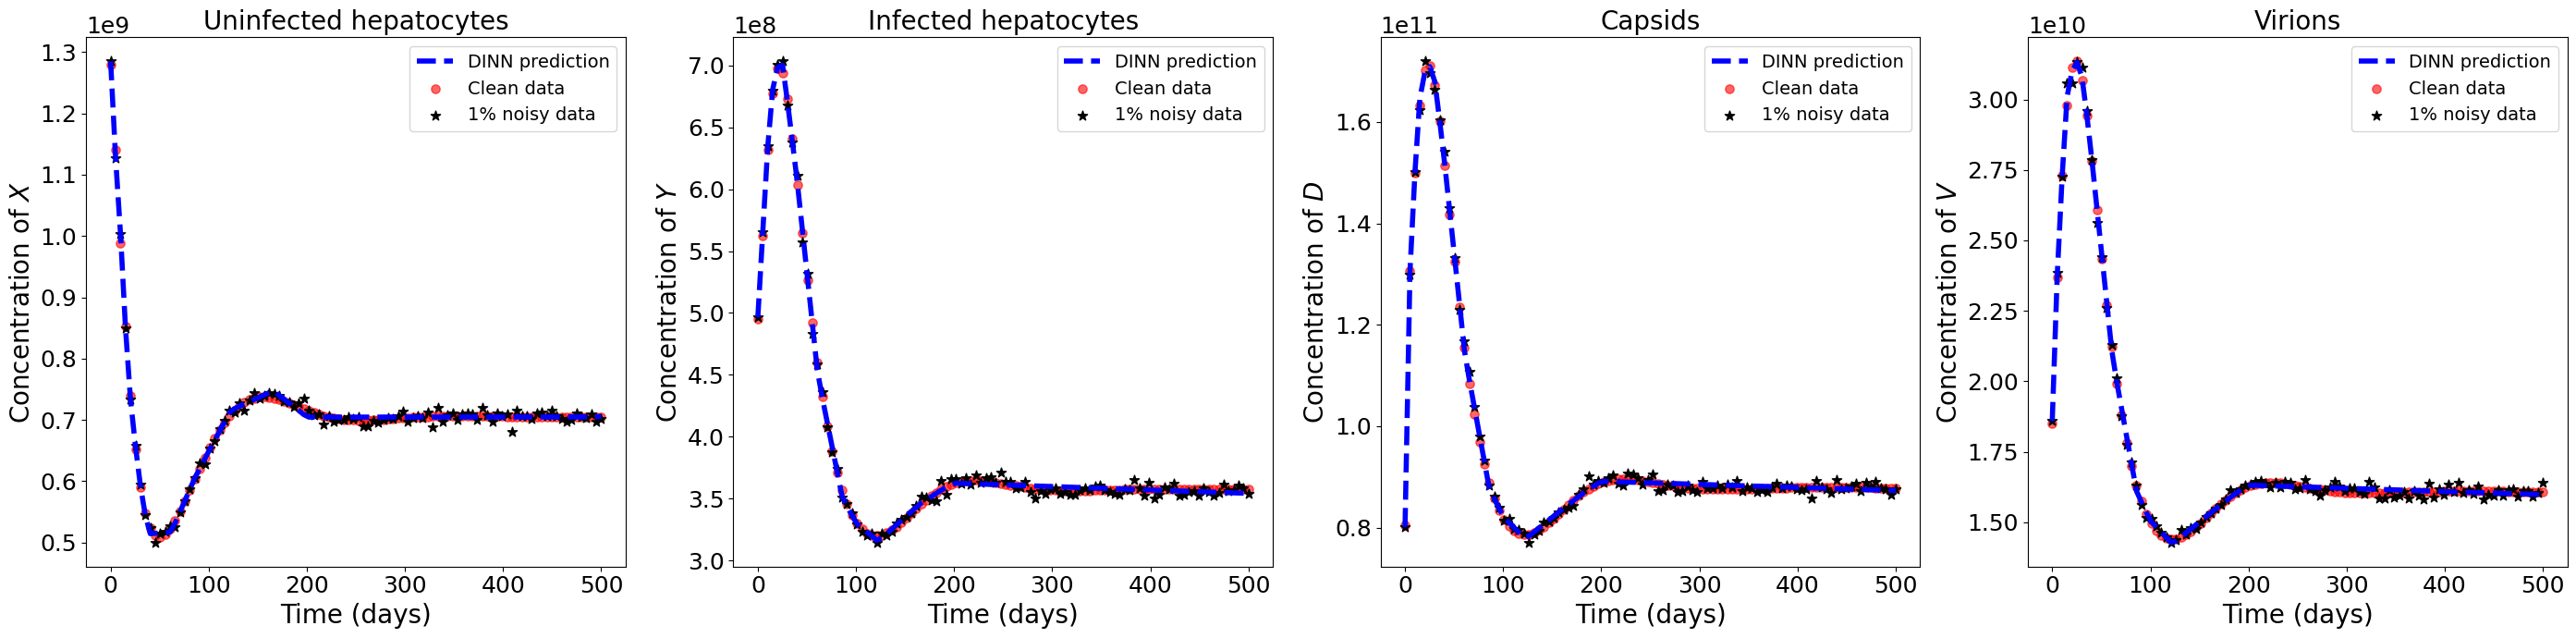

In [ ]:
# ============================================================
# Cell 9: Plot clean data, 1% noisy data, and DINN predictions
# ============================================================

fig, axs = plt.subplots(1, 4, figsize=(28, 7))
fig.patch.set_facecolor("white")

ax1, ax2, ax3, ax4 = axs.flatten()

# X
ax1.plot(t_data, X_pred, color="blue", lw=4, label="DINN prediction", linestyle="dashed")
ax1.scatter(t_data, X_clean, color="red", alpha=0.6, label="Clean data", s=45)
ax1.scatter(t_data, X_data, color="black", alpha=1.0, label="1% noisy data", s=60, marker="*")
ax1.set_title("Uninfected hepatocytes", fontsize=20)
ax1.set_xlabel("Time (days)", fontsize=20)
ax1.set_ylabel(r"Concentration of $X$", fontsize=20)
ax1.legend(fontsize=14)
ax1.tick_params(axis="both", labelsize=18)
ax1.yaxis.get_offset_text().set_fontsize(18)

# Y
ax2.plot(t_data, Y_pred, color="blue", lw=4, label="DINN prediction", linestyle="dashed")
ax2.scatter(t_data, Y_clean, color="red", alpha=0.6, label="Clean data", s=45)
ax2.scatter(t_data, Y_data, color="black", alpha=1.0, label="1% noisy data", s=60, marker="*")
ax2.set_title("Infected hepatocytes", fontsize=20)
ax2.set_xlabel("Time (days)", fontsize=20)
ax2.set_ylabel(r"Concentration of $Y$", fontsize=20)
ax2.legend(fontsize=14)
ax2.tick_params(axis="both", labelsize=18)
ax2.yaxis.get_offset_text().set_fontsize(18)

# D
ax3.plot(t_data, D_pred, color="blue", lw=4, label="DINN prediction", linestyle="dashed")
ax3.scatter(t_data, D_clean, color="red", alpha=0.6, label="Clean data", s=45)
ax3.scatter(t_data, D_data, color="black", alpha=1.0, label="1% noisy data", s=60, marker="*")
ax3.set_title("Capsids", fontsize=20)
ax3.set_xlabel("Time (days)", fontsize=20)
ax3.set_ylabel(r"Concentration of $D$", fontsize=20)
ax3.legend(fontsize=14)
ax3.tick_params(axis="both", labelsize=18)
ax3.yaxis.get_offset_text().set_fontsize(18)

# V
ax4.plot(t_data, V_pred, color="blue", lw=4, label="DINN prediction", linestyle="dashed")
ax4.scatter(t_data, V_clean, color="red", alpha=0.6, label="Clean data", s=45)
ax4.scatter(t_data, V_data, color="black", alpha=1.0, label="1% noisy data", s=60, marker="*")
ax4.set_title("Virions", fontsize=20)
ax4.set_xlabel("Time (days)", fontsize=20)
ax4.set_ylabel(r"Concentration of $V$", fontsize=20)
ax4.legend(fontsize=14)
ax4.tick_params(axis="both", labelsize=18)
ax4.yaxis.get_offset_text().set_fontsize(18)

plt.tight_layout()
plt.show()

## Cell 10: Calculate and print RRMSE errors

This cell computes the relative root mean square error (RRMSE) between the clean data and the DINN predictions for each state variable.

In [ ]:
# ============================================================
# Cell 10: Calculate and print RRMSE errors
# ============================================================
# RRMSE = sqrt(sum((clean - predicted)^2) / sum(clean^2))

def rrmse_error(clean, pred):
    return np.sqrt(np.sum((clean - pred) ** 2) / np.sum(clean ** 2))

X_RRMSE = rrmse_error(X_clean, X_pred)
Y_RRMSE = rrmse_error(Y_clean, Y_pred)
D_RRMSE = rrmse_error(D_clean, D_pred)
V_RRMSE = rrmse_error(V_clean, V_pred)

rrmse_df = pd.DataFrame({
    "variable": ["X", "Y", "D", "V"],
    "RRMSE_error_wrt_clean_data": [
        X_RRMSE,
        Y_RRMSE,
        D_RRMSE,
        V_RRMSE
    ]
})

print("RRMSE errors with respect to clean data:")
print(rrmse_df)

RRMSE errors with respect to clean data:
  variable  RRMSE_error_wrt_clean_data
0        X                    0.005649
1        Y                    0.005639
2        D                    0.005504
3        V                    0.005358
